# 0.34 — Quantum: does the basket beat the quantum ETF, or just the market?

`0.33` tested genAI against the S&P 500 only, because no genAI ETF existed at the promotion
date. **Quantum is the better test**: the Defiance Quantum ETF (`QTUM`) has traded since
2018-09-04, so we can ask the sharper question —

> is this a *decent quantum basket*, or would you just have bought the specialist ETF?

## The setup, in full

**One vocabulary** — the obvious word plus the phrases that pin down the technology:

```
quantum · quantum computing · quantum computer · qubit · quantum annealing ·
superconducting qubit · trapped ion · quantum supremacy · post-quantum ·
quantum error correction · quantum sensing · quantum key distribution
```

**Three dates**, each with a live ETF to compare against:

| date | what happened | why this date |
|---|---|---|
| **2018-09-04** | the `QTUM` ETF lists | buy on its first traded day, 2018-09-05 |
| **2022-09-30** | — | first quarter-end at which **all four** quantum pure-plays have filed with the SEC (D-Wave's first filing is 2022-08-26) |
| **2025-01-15** | the `CHPX` ETF lists | the theme is loud in filings by now |

The 2018 and 2025 dates come from `0.24`'s "investability dates". 2022 is chosen by a rule,
not by hindsight: it is the first quarter-end at which the companies existed as filers.

**The test**: equal-weight, buy and hold, no costs, compared against `QTUM` and the S&P 500.
Prices are Yahoo adjusted closes. As in `0.33`, the universe is *today's* ticker file, so
companies that delisted cannot drag the basket down — read the numbers as optimistic.

In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
import pandas as pd

import theme_backtest as bt

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
BLUE, YELLOW, AQUA, RED, GRAY = "#2a78d6", "#eda100", "#1baf7a", "#d62728", "#8a8a8a"
PROC = "../data/processed"

D2018, D2022, D2025 = "2018-09-05", "2022-09-30", "2025-01-15"   # QTUM's 1st price is 2018-09-05
load = lambda n: pd.read_parquet(f"{PROC}/theme_basket_{n}.parquet")

# the same 12-term vocabulary at all three dates
b18 = load("quantum2018_bare_pit")
b22 = load("quantum2022_bare_pit")
b25 = load("quantum2025_bare_pit")

px = bt.load_prices(sorted({t for b in (b18, b22, b25) for t in b.ticker} | {"QTUM", "SPY"}))
for lbl, b, n in [("2018", b18, 183), ("2022", b22, 274), ("2025", b25, 412)]:
    print(f"{lbl} basket: {len(b):3d} companies from {n} filings")

2018 basket: 111 companies from 183 filings
2022 basket: 156 companies from 274 filings
2025 basket: 238 companies from 412 filings


## 1. The same theme, three different filing regimes

How many 10-K/10-Q filings contain each term in the year before each date?

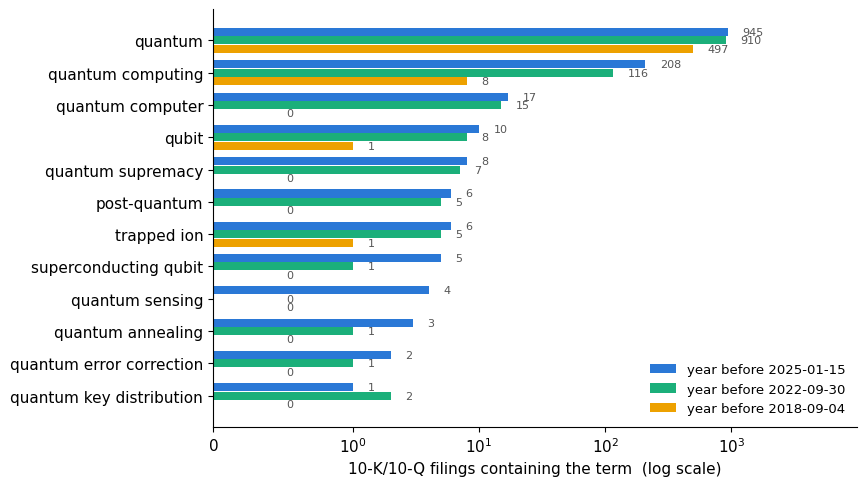

In [2]:
TOTALS = pd.DataFrame({
    "2018": {"quantum": 497, "quantum computing": 8, "quantum computer": 0, "qubit": 1,
             "quantum annealing": 0, "superconducting qubit": 0, "trapped ion": 1,
             "quantum supremacy": 0, "post-quantum": 0, "quantum error correction": 0,
             "quantum sensing": 0, "quantum key distribution": 0},
    "2022": {"quantum": 910, "quantum computing": 116, "quantum computer": 15, "qubit": 8,
             "quantum annealing": 1, "superconducting qubit": 1, "trapped ion": 5,
             "quantum supremacy": 7, "post-quantum": 5, "quantum error correction": 1,
             "quantum sensing": 0, "quantum key distribution": 2},
    "2025": {"quantum": 945, "quantum computing": 208, "quantum computer": 17, "qubit": 10,
             "quantum annealing": 3, "superconducting qubit": 5, "trapped ion": 6,
             "quantum supremacy": 8, "post-quantum": 6, "quantum error correction": 2,
             "quantum sensing": 4, "quantum key distribution": 1}}).sort_values("2025")

fig, ax = plt.subplots(figsize=(8.8, 5.0))
y = range(len(TOTALS))
for off, col, color, lab in [(0.26, "2025", BLUE, "year before 2025-01-15"),
                             (0.0, "2022", AQUA, "year before 2022-09-30"),
                             (-0.26, "2018", YELLOW, "year before 2018-09-04")]:
    ax.barh([i + off for i in y], TOTALS[col], height=0.25, color=color, label=lab)
    for i, v in enumerate(TOTALS[col]):
        ax.text(max(v, 0.4) * 1.3, i + off, str(v), va="center", fontsize=8, color="#555")
ax.set_yticks(list(y)); ax.set_yticklabels(TOTALS.index)
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("10-K/10-Q filings containing the term  (log scale)")
ax.legend(fontsize=9.5, frameon=False, loc="lower right")
ax.margins(x=0.25)
fig.tight_layout(); plt.show()

Two things to read here.

**The regime split, in three steps.** `quantum computing` goes **8 → 116 → 208** filings, and
the precise vocabulary (`superconducting qubit`, `trapped ion`, `quantum error correction`)
from literally zero, to a trickle, to consistently present. Quantum was a decades-old research
topic in 2018 — but no *public company* had commercial exposure to write about yet.
**A theme can be old and still invisible in filings.** By 2022 the pure-plays have listed
(mostly via SPAC) and the channel switches on.

**The bare word barely notices.** `quantum` goes 497 → 910 → 945 — essentially flat after
2018 — while the phrase goes 8 → 116 → 208, some 26×. The common word is mostly measuring something else — companies with
"Quantum" in their name, and *Quantum of the Seas*, a Royal Caribbean cruise ship. Section 6
shows this does no harm, because of how the scorer ranks.

## 2. 2018: the basket the pipeline builds is a bad one

In [3]:
b18.head(8).assign(rank=b18.head(8).index + 1)[
    ["rank", "ticker", "company", "total", "n_terms_hit", "per_1k_words"]]

,rank,ticker,company,total,n_terms_hit,per_1k_words
0,1,MRSH,"MARSH & MCLENNAN COMPANIES, INC.",4,2,0.838
1,2,AMPG,"AmpliTech Group, Inc.",2,2,0.146
2,3,IBM,INTERNATIONAL BUSINESS MACHINES CORP,12,2,0.119
3,4,ACN,Accenture plc,2,2,0.037
4,5,BAH,Booz Allen Hamilton Holding Corp,2,2,0.027
5,6,NOVT,NOVANTA INC,226,1,1.663
6,7,NKE,"NIKE, Inc.",1,1,1.290
7,8,QMCO,QUANTUM CORP /DE/,37,1,1.239


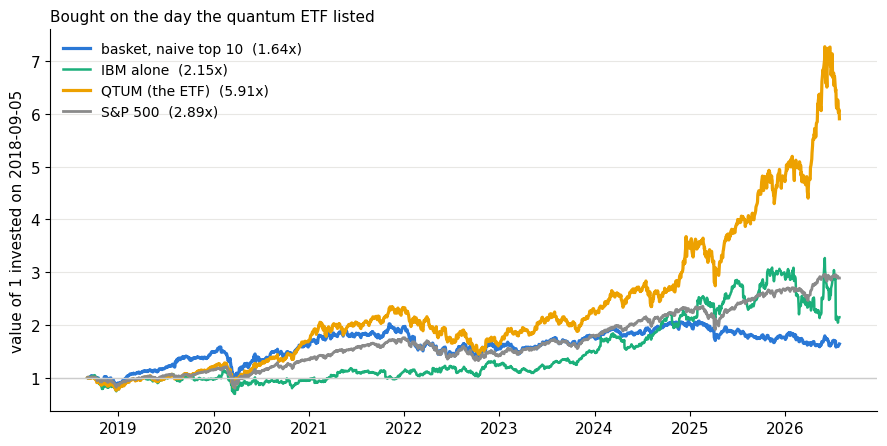

In [4]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))
for label, tk, color, lw in [("basket, naive top 10", b18.head(10).ticker.tolist(), BLUE, 2.3),
                             ("IBM alone", ["IBM"], AQUA, 1.8),
                             ("QTUM (the ETF)", ["QTUM"], YELLOW, 2.3),
                             ("S&P 500", ["SPY"], GRAY, 2.0)]:
    curve, _, _ = bt.equal_weight_curve(px, tk, D2018)
    ax.plot(curve.index, curve.values, color=color, lw=lw, label=f"{label}  ({curve.iloc[-1]:.2f}x)")
ax.axhline(1, color="#ccc", lw=1)
ax.set_ylabel("value of 1 invested on 2018-09-05")
ax.set_title("Bought on the day the quantum ETF listed", fontsize=11, loc="left")
ax.legend(fontsize=10, frameon=False)
ax.grid(axis="y", color="#e8e7e4", lw=0.8); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

Only **five** companies mention more than one quantum term, and they are Marsh & McLennan
(insurance broking), AmpliTech, IBM, Accenture and Booz Allen. Apart from IBM these are
consultancies and brokers with a single "technologies that may disrupt our industry"
sentence. Everything below them hits exactly one term — and it is the bare word, so it is
Novanta, Nike and Quantum Corp.

Over the following 7.9 years the naive top-10 returned **+64%**, against the S&P's **+189%**
and QTUM's **+491%**. Buying IBM alone (+115%) would have beaten it.

**The pipeline was asked "who is active in quantum?" in a year when the honest answer was
"nobody you can buy" — and it answered with seven consultancies instead of with silence.**
Remember that: it is what the selection rule in section 4 has to fix.

## 3. 2022 and 2025: the same vocabulary finds the real companies

No hand-holding, no company names in the vocabulary — at **both** dates the top four *are*
the pure-plays, and there is a visible cliff in density right underneath them.

In [5]:
cols = ["rank", "ticker", "company", "n_filings", "total", "n_terms_hit", "per_1k_words"]
print("2022-09-30")
display(b22.head(8).assign(rank=b22.head(8).index + 1)[cols])
print("2025-01-15")
display(b25.head(8).assign(rank=b25.head(8).index + 1)[cols])

2022-09-30


,rank,ticker,company,n_filings,total,n_terms_hit,per_1k_words
0,1,IONQ,"IonQ, Inc.",4,1797,8,8.601
1,2,QUBT,Quantum Computing Inc.,4,1007,5,12.244
2,3,RGTI,"Rigetti Computing, Inc.",2,646,5,5.513
3,4,QBTS,D-Wave Quantum Inc.,1,166,3,6.834
4,5,LODE,Comstock Inc.,4,121,3,0.698
5,6,IBM,INTERNATIONAL BUSINESS MACHINES CORP,4,44,3,0.157
6,7,RBBN,Ribbon Communications Inc.,1,3,3,0.038
7,8,BZAI,"Blaize Holdings, Inc.",1,26,2,0.925


2025-01-15


,rank,ticker,company,n_filings,total,n_terms_hit,per_1k_words
0,1,IONQ,"IonQ, Inc.",4,2172,8,10.034
1,2,RGTI,"Rigetti Computing, Inc.",4,1203,8,6.962
2,3,QBTS,D-Wave Quantum Inc.,8,2540,6,7.668
3,4,QUBT,Quantum Computing Inc.,4,778,5,6.073
4,5,UIS,UNISYS CORP,1,14,4,0.262
5,6,RBBN,Ribbon Communications Inc.,1,5,4,0.069
6,7,ASPI,ASP Isotopes Inc.,4,170,2,1.143
7,8,MRSH,"MARSH & MCLENNAN COMPANIES, INC.",1,4,2,0.790


## 4. The fix: stop taking "the top N"

The naive recipe says take the top 10. Watch what that costs — same scores, same ranking,
only the cutoff changes.

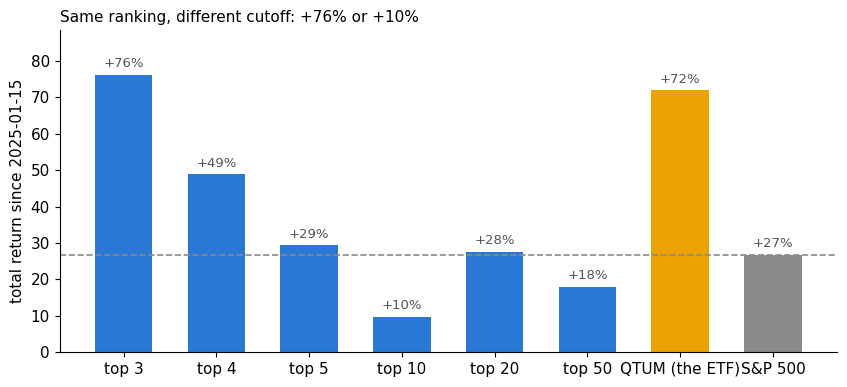

In [6]:
CUTS = [3, 4, 5, 10, 20, 50]
rows = [{"basket": f"top {n}",
         "total return": float(bt.equal_weight_curve(px, b25.head(n).ticker.tolist(), D2025)[0].iloc[-1] - 1)}
        for n in CUTS]
for label, tk in [("QTUM (the ETF)", ["QTUM"]), ("S&P 500", ["SPY"])]:
    rows.append({"basket": label,
                 "total return": float(bt.equal_weight_curve(px, tk, D2025)[0].iloc[-1] - 1)})
cut = pd.DataFrame(rows).set_index("basket")

fig, ax = plt.subplots(figsize=(8.6, 4.0))
ax.bar(cut.index, 100 * cut["total return"], color=[BLUE] * len(CUTS) + [YELLOW, GRAY], width=0.62)
for i, v in enumerate(cut["total return"]):
    ax.text(i, 100 * v + 2, f"{v:+.0%}", ha="center", fontsize=9.5, color="#555")
ax.axhline(100 * cut.loc["S&P 500", "total return"], color=GRAY, ls="--", lw=1.2)
ax.set_ylabel("total return since 2025-01-15")
ax.set_title("Same ranking, different cutoff: +76% or +10%", fontsize=11, loc="left")
ax.margins(y=0.16)
fig.tight_layout(); plt.show()

**Top 3 returns +76% and beats the ETF. Top 10 returns +10% and loses to the S&P.** The
ranking is fine; the arbitrary cutoff throws the result away. Names 5–10 mention quantum once
or twice in passing, and they are the ones that lost money.

### Two columns already in the table separate the two groups

- `n_terms_hit` — **how many different** quantum terms the company uses. A real player uses
  the whole vocabulary; a passing mention uses one word.
- `per_1k_words` — **how densely**. An order-of-magnitude gap.

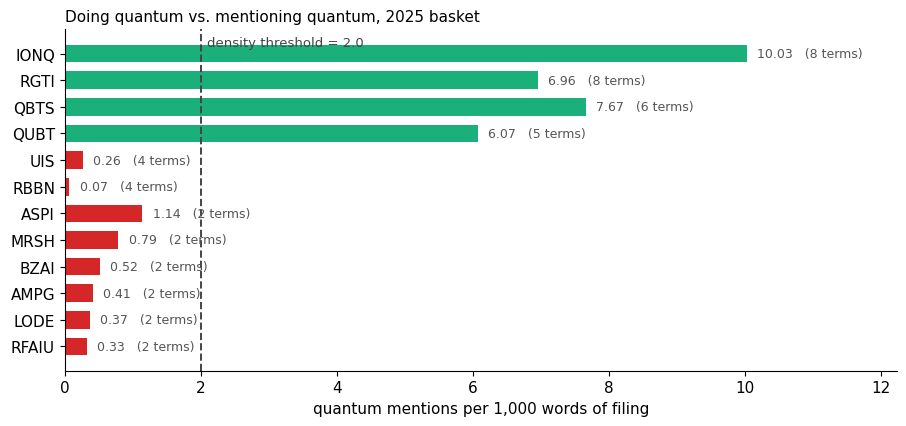

In [7]:
top = b25.head(12)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
colors = [AQUA if (d >= 2.0 and k >= 2) else RED
          for d, k in zip(top.per_1k_words, top.n_terms_hit)]
ax.barh(top.ticker[::-1], top.per_1k_words[::-1], color=colors[::-1], height=0.66)
ax.axvline(2.0, color="#444", lw=1.4, ls="--")
ax.text(2.1, 11.3, "density threshold = 2.0", fontsize=9.5, color="#444")
for i, (v, k) in enumerate(zip(top.per_1k_words[::-1], top.n_terms_hit[::-1])):
    ax.text(v + 0.15, i, f"{v:.2f}   ({k} terms)", va="center", fontsize=9, color="#555")
ax.set_xlabel("quantum mentions per 1,000 words of filing")
ax.set_title("Doing quantum vs. mentioning quantum, 2025 basket", fontsize=11, loc="left")
ax.margins(x=0.22)
fig.tight_layout(); plt.show()

In [8]:
RULE = "per_1k_words >= 2.0 and n_terms_hit >= 2"
pick = lambda b: b[(b.per_1k_words >= 2.0) & (b.n_terms_hit >= 2)].ticker.tolist()

for label, b in [("2018-09-04", b18), ("2022-09-30", b22), ("2025-01-15", b25)]:
    sel = pick(b)
    print(f"{label}: rule selects {len(sel)} companies -> {sel if sel else 'NO TRADE'}")

2018-09-04: rule selects 0 companies -> NO TRADE
2022-09-30: rule selects 4 companies -> ['IONQ', 'QUBT', 'RGTI', 'QBTS']
2025-01-15: rule selects 4 companies -> ['IONQ', 'RGTI', 'QBTS', 'QUBT']


**One rule — `density >= 2.0` and `at least 2 distinct terms` — does the job at all three
dates.**

In 2022 and 2025 it selects exactly the four pure-plays. In 2018 it selects **nothing at
all**, which is the correct answer and the thing "take the top N" structurally cannot say.
A basket that can be *empty* is a basket that knows when a theme is not yet investable
through filings.

Note that 2022 is a genuine **out-of-sample** check: the threshold was picked looking at 2025
and 2018, and applied unchanged to a date in between. (It is not delicate either — anything
from 1.5 to 3.0 gives the identical selection at all three dates.)

## 5. The market test — and why the entry date decides everything

Same rule, same four companies, two entry dates.

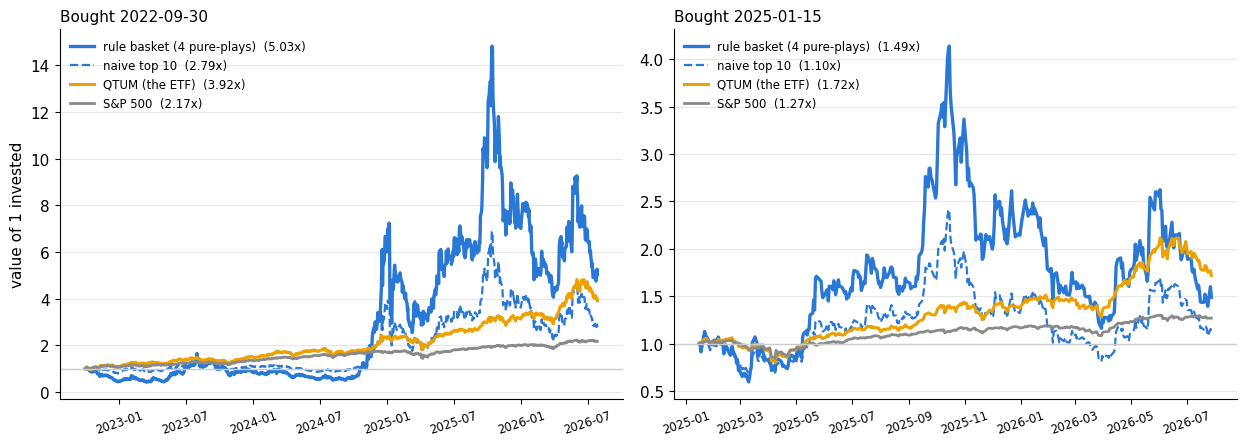

--- bought 2022-09-30 ---
  vs QTUM:  3m -62pp   6m -80pp   12m -29pp   24m -113pp   36m +663pp   all (3.8y) +112pp
  vs SPY:  3m -61pp   6m -67pp   12m -17pp   24m -102pp   36m +767pp   all (3.8y) +286pp
--- bought 2025-01-15 ---
  vs QTUM:  3m -8pp   6m +48pp   12m +89pp   18m -31pp   all (1.5y) -23pp
  vs SPY:  3m -10pp   6m +58pp   12m +119pp   18m +25pp   all (1.5y) +22pp


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for ax, (when, b, title) in zip(axes, [(D2022, b22, "Bought 2022-09-30"),
                                       (D2025, b25, "Bought 2025-01-15")]):
    sel = pick(b)
    for label, tk, color, ls, lw in [("rule basket (4 pure-plays)", sel, BLUE, "-", 2.4),
                                     ("naive top 10", b.head(10).ticker.tolist(), BLUE, "--", 1.6),
                                     ("QTUM (the ETF)", ["QTUM"], YELLOW, "-", 2.2),
                                     ("S&P 500", ["SPY"], GRAY, "-", 2.0)]:
        curve, _, _ = bt.equal_weight_curve(px, tk, when)
        ax.plot(curve.index, curve.values, color=color, ls=ls, lw=lw,
                label=f"{label}  ({curve.iloc[-1]:.2f}x)")
    ax.axhline(1, color="#ccc", lw=1)
    ax.set_title(title, fontsize=11, loc="left")
    ax.legend(fontsize=8.5, frameon=False, loc="upper left")
    ax.grid(axis="y", color="#e8e7e4", lw=0.8); ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=8.5, rotation=18)
axes[0].set_ylabel("value of 1 invested")
fig.tight_layout(); plt.show()

for when, b, hor in [(D2022, b22, [3, 6, 12, 24, 36]), (D2025, b25, [3, 6, 12, 18])]:
    print(f"--- bought {when} ---")
    for bench in ["QTUM", "SPY"]:
        h = bt.horizon_table(px, pick(b), when, benchmark=bench, horizons=hor)
        print(f"  vs {bench}:  " + "   ".join(f"{i} {100 * r['excess']:+.0f}pp" for i, r in h.iterrows()))

**Bought in 2022, the basket wins outright: +403%, against QTUM's +292% and the S&P's +117%.**
All four names are up (Rigetti +672%, IonQ +608%, QUBT +208%, D-Wave +124%), and the rule
basket more than doubles the naive top 10 (+179%).

**Bought in 2025, the same four names beat the market (+22pp) but lose to the ETF (−23pp).**

The horizon rows explain the difference, and they are the uncomfortable part. From the 2022
entry the basket was **62pp behind QTUM at 3 months, 80pp behind at 6, and still 113pp behind
at two years** — before adding +663pp in year three. The entire result is the late-2024/2025
quantum rally. A desk reviewing this position quarterly would have closed it long before it
paid, exactly as in `0.33`.

So the honest reading is that **filings tell you *which* four companies, not *when* to own
them.** Selection is where the pipeline adds value; timing it does not.

## 6. Does the vocabulary actually matter? (two sanity checks)

Both checks say **no — once the selection rule is right, the vocabulary details wash out.**

In [10]:
alt = {"as above (12 terms, incl. 'quantum')": b25,
       "drop the bare word 'quantum'": load("quantum2025_pit"),
       "add company names (ionq, rigetti, d-wave, quantinuum)": load("quantum2025_names_pit")}
rows = []
for label, b in alt.items():
    sel = b[(b.per_1k_words >= 2.0) & (b.n_terms_hit >= 2)].ticker.tolist()
    ret = float(bt.equal_weight_curve(px, sel, D2025)[0].iloc[-1] - 1) if sel else float("nan")
    rows.append({"vocabulary": label, "companies in basket": len(b),
                 "rule selects": ", ".join(sel), "return": f"{ret:+.1%}"})
pd.DataFrame(rows).set_index("vocabulary")

,companies in basket,rule selects,return
vocabulary,,,
"as above (12 terms, incl. 'quantum')",238,"IONQ, RGTI, QBTS, QUBT",+48.8%
drop the bare word 'quantum',81,"IONQ, RGTI, QUBT",-3.1%
"add company names (ionq, rigetti, d-wave, quantinuum)",83,"IONQ, RGTI, QBTS, QUBT",+48.8%


In [11]:
# where do the "Quantum"-named impostors actually rank?
for t in ["QSI", "QMCO", "RCL", "HCI"]:
    r = b25[b25.ticker == t]
    if len(r):
        print(f"{t:5s} {r.company.iloc[0][:30]:32s} rank {r.index[0] + 1:3d} | "
              f"{int(r.n_terms_hit.iloc[0])} term | density {r.per_1k_words.iloc[0]:.2f}")

QSI   Quantum-Si Inc                   rank  83 | 1 term | density 1.86
QMCO  QUANTUM CORP /DE/                rank  85 | 1 term | density 1.35
RCL   ROYAL CARIBBEAN CRUISES LTD      rank 123 | 1 term | density 0.09
HCI   HCI Group, Inc.                  rank 127 | 1 term | density 0.08


**Keeping the bare word `quantum` is safe.** It triples the download (412 filings vs 128) and
changes the final selection not at all. The companies it drags in — Quantum-Si (protein
sequencing), Quantum Corp (tape storage), Royal Caribbean — land at ranks **83, 85 and 123**,
because they hit **one** term. The `>= 2 distinct terms` condition removes them without ever
needing a special case.

One caveat worth keeping: adding a high-frequency word inflates every density (IonQ goes 3.9
→ 10.0), so the threshold must be **calibrated against the vocabulary in use**, not copied
between themes. A relative cutoff would be more portable.

**Adding the company names is also harmless but pointless** — it inflates the pure-plays'
scores through self-mention (D-Wave 545 → 2,495 mentions, mostly the company saying
"D-Wave") and selects the same four. The concept words had already found them, which is
`0.33`'s recommendation #1 confirmed: you do not need company names in the vocabulary.

## 7. Takeaways

1. **The best result the component has produced.** From filings alone, with no company names,
   the scorer identified IonQ, Rigetti, D-Wave and QUBT — at *both* 2022 and 2025 — and the
   2022 entry beat the ETF (+112pp) and the market (+286pp).

2. **But the entry date decides the verdict, not the selection.** The identical four names
   bought in 2025 beat the market by 22pp and *lose* to QTUM by 23pp. And even the winning
   2022 entry was 113pp behind the ETF at the two-year mark. Filings tell you *which*
   companies; they say nothing about *when*.

3. **The cutoff, not the ranking, was the flaw in v1.** Identical scores: top 3 = +76%,
   top 10 = +10%. `top N` is the single worst design decision in the current scorer.

4. **Replace it with `density >= 2.0` and `>= 2 distinct terms`.** It picks exactly the right
   four companies at both 2022 and 2025 — the 2022 date being genuinely out-of-sample — and
   **nothing at all in 2018**. A basket that can be empty is the feature the 2018 case needed.

5. **A theme can be old and still filing-invisible.** Quantum research was decades old in
   2018; no public company sold it yet, so the filings had nothing to say. Detection date is
   not the same as investability date.

6. **The vocabulary is not the fragile part — the selection rule is.** Adding or removing the
   bare word `quantum`, or the company names, does not change the selected basket at all.

### Reproduce

```bash
python scripts/build_theme_basket.py --name quantum2025_bare_pit --as-of 2025-01-15 \
  --lookback 365 --lookahead 0 \
  --vocab quantum "quantum computing" "quantum computer" qubit "quantum annealing" \
          "superconducting qubit" "trapped ion" "quantum supremacy" post-quantum \
          "quantum error correction" "quantum sensing" "quantum key distribution"
```